# Simulación del Juego Yahtzee - Método de Montecarlo
**Materia:** Simulación
**Estudiante:** Santiago Sanchez Salazar

Este Notebook contiene la implementación de un simulador de Yahtzee para 2 jugadores. El objetivo es aplicar el **Método de Montecarlo** para observar el comportamiento de los puntajes y la frecuencia de las jugadas tras múltiples iteraciones.

### Reglas básicas implementadas:
* 5 dados de 6 caras (distribución uniforme).
* Hasta 3 lanzamientos por turno.
* 2 jugadores compitiendo.
* Análisis estadístico final de los resultados.

In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import collections

# Configuración de las gráficas
%matplotlib inline

### 1. Definición de funciones base
Implementamos la generación de números pseudoaleatorios con distribución uniforme.

In [2]:
def lanzar_dados(n):
    """Genera n números aleatorios entre 1 y 6 (Distribución Uniforme)."""
    return [random.randint(1, 6) for _ in range(n)]

# Prueba rápida
print(f"Lanzamiento de prueba: {lanzar_dados(5)}")

Lanzamiento de prueba: [6, 2, 6, 5, 2]


### 2. Lógica de puntuación
Definimos cómo el programa evalúa si los dados forman una jugada valiosa.

In [3]:
def calcular_puntuacion(dados):
    """
    Evalúa los dados y retorna un diccionario con los puntos posibles
    en las categorías principales.
    """
    counts = collections.Counter(dados)
    max_freq = max(counts.values())
    suma_total = sum(dados)
    
    puntos = {
        "Yahtzee": 50 if max_freq == 5 else 0,
        "Poker": suma_total if max_freq >= 4 else 0,
        "Full House": 25 if sorted(counts.values()) == [2, 3] else 0,
        "Trio": suma_total if max_freq >= 3 else 0,
        "Suma Total": suma_total
    }
    
    # Escaleras (simplificado)
    dados_unicos = sorted(list(set(dados)))
    if len(dados_unicos) >= 5 and (dados_unicos[-1] - dados_unicos[0] == 4):
        puntos["Escalera"] = 40
    else:
        puntos["Escalera"] = 0
        
    return puntos

### 3. Simulación del turno con estrategia
Aquí aplicamos la lógica de decisión: el jugador intenta conservar los dados repetidos para maximizar puntos en los 3 intentos.

In [4]:
def simular_turno():
    """
    Simula un turno completo (hasta 3 lanzamientos) con una estrategia básica:
    Mantener los dados que más se repiten.
    """
    # Primer lanzamiento
    mano = lanzar_dados(5)
    
    for intento in range(2): # 2 intentos extra
        counts = collections.Counter(mano)
        # Buscamos cuál es el valor que más se repite para quedárnoslo
        valor_frecuente = counts.most_common(1)[0][0]
        n_repetidos = counts.most_common(1)[0][1]
        
        # Si ya tenemos Yahtzee, no volvemos a lanzar
        if n_repetidos == 5:
            break
            
        # Volvemos a lanzar solo los dados que NO son el valor frecuente
        nuevos_dados = lanzar_dados(5 - n_repetidos)
        mano = [valor_frecuente] * n_repetidos + nuevos_dados
        
    return calcular_puntuacion(mano)

### 4. Ejecución de Montecarlo
Corremos miles de turnos para explotar los resultados aleatorios y simular múltiples partidas entre los 2 jugadores.

In [5]:
def ejecutar_montecarlo(n_partidas=1000):
    """
    Ejecuta la simulación masiva para obtener datos estadísticos.
    """
    resultados_j1 = []
    resultados_j2 = []
    yahtzees_totales = 0
    
    for _ in range(n_partidas):
        # Simulamos un juego de 13 turnos por jugador
        puntaje_partida_j1 = 0
        puntaje_partida_j2 = 0
        
        for turno in range(13):
            # Turno Jugador 1
            res_j1 = simular_turno()
            # Estrategia muy simple: anotar la máxima puntuación lograda en el turno
            puntaje_partida_j1 += max(res_j1.values())
            if res_j1["Yahtzee"] > 0: yahtzees_totales += 1
            
            # Turno Jugador 2
            res_j2 = simular_turno()
            puntaje_partida_j2 += max(res_j2.values())
            if res_j2["Yahtzee"] > 0: yahtzees_totales += 1
            
        resultados_j1.append(puntaje_partida_j1)
        resultados_j2.append(puntaje_partida_j2)
        
    return resultados_j1, resultados_j2, yahtzees_totales

# Corremos la simulación con 1000 partidas
n_sim = 1000
res_j1, res_j2, total_y = ejecutar_montecarlo(n_sim)

print(f"--- Simulación terminada para {n_sim} partidas ---")
print(f"Puntaje promedio J1: {sum(res_j1)/n_sim:.2f}")
print(f"Puntaje promedio J2: {sum(res_j2)/n_sim:.2f}")
print(f"Total de Yahtzees conseguidos en las {n_sim} partidas: {total_y}")

--- Simulación terminada para 1000 partidas ---
Puntaje promedio J1: 258.30
Puntaje promedio J2: 257.37
Total de Yahtzees conseguidos en las 1000 partidas: 1221


### 5. Visualización de Resultados
Analizamos la distribución de los puntajes obtenidos usando un histograma, lo cual es fundamental en el método de Montecarlo para ver el comportamiento del sistema.

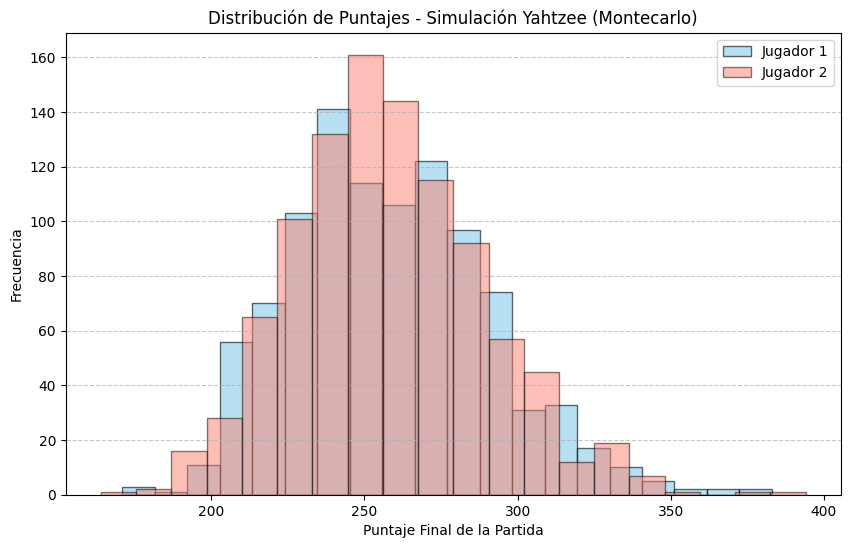


Resumen Estadístico:
         Jugador 1    Jugador 2
count  1000.000000  1000.000000
mean    258.298000   257.367000
std      32.294491    30.821101
min     171.000000   164.000000
25%     235.000000   235.750000
50%     256.000000   255.000000
75%     279.000000   277.000000
max     383.000000   394.000000


In [6]:
# Análisis de resultados
df = pd.DataFrame({'Jugador 1': res_j1, 'Jugador 2': res_j2})

plt.figure(figsize=(10,6))
plt.hist(df['Jugador 1'], bins=20, alpha=0.6, label='Jugador 1', color='skyblue', edgecolor='black')
plt.hist(df['Jugador 2'], bins=20, alpha=0.5, label='Jugador 2', color='salmon', edgecolor='black')
plt.title('Distribución de Puntajes - Simulación Yahtzee (Montecarlo)')
plt.xlabel('Puntaje Final de la Partida')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nResumen Estadístico:")
print(df.describe())